In [3]:
#Karthick N 
#24BAD055

#Import libraries
import pandas as pd
import numpy as np
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Model
from sklearn.naive_bayes import MultinomialNB

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [4]:
#load the dataset
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
#Text cleaning
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['message'] = df['message'].apply(clean_text)

In [6]:
#Convert Text into Numerical Features
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['message'])

In [7]:
#. Encode Target Labels
encoder = LabelEncoder()
y = pd.Series(encoder.fit_transform(df['label']))

In [8]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
#Train multinomial naive bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [10]:
#Prediction
y_pred = model.predict(X_test)

In [11]:
#Evalation metrices
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.97847533632287
Precision: 0.92
Recall: 0.92
F1 Score: 0.92


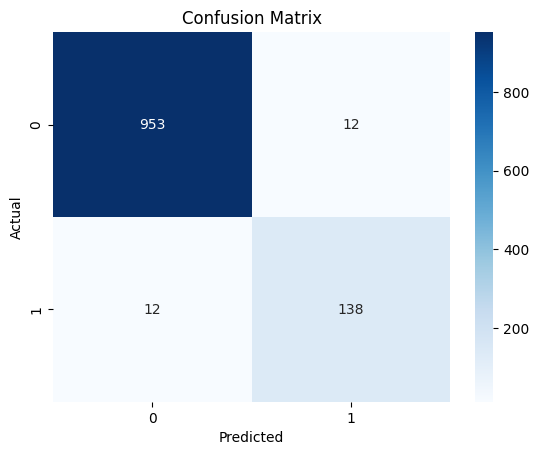

In [12]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
#Feature importance
feature_names = vectorizer.get_feature_names_out()
log_probs = model.feature_log_prob_[1]   # Spam class

top10 = np.argsort(log_probs)[-10:]

for i in top10:
    print(feature_names[i])

is
now
or
the
for
free
your
you
call
to


In [14]:
#Word frequency comparison
spam_words = df[df['label']=='spam']['message']
ham_words = df[df['label']=='ham']['message']

spam_vector = vectorizer.fit_transform(spam_words)
ham_vector = vectorizer.fit_transform(ham_words)

print("Top spam words:", spam_vector.sum(axis=0))
print("Top ham words:", ham_vector.sum(axis=0))

Top spam words: [[2 1 1 ... 1 1 1]]
Top ham words: [[1 9 1 ... 1 9 1]]


In [15]:
#Misclassified examples
misclassified = df.iloc[y_test.index][y_test != y_pred]
print(misclassified.head())

     label                                            message
3245   ham  funny fact nobody teaches volcanoes 2 erupt ts...
3142   ham  boy i love u grl hogolo boy gold chain kodstin...
683   spam  hi im sue i am 20 years old and work as a lapd...
3504   ham              life alle moneeppolum oru pole allalo
4328   ham  1appledayno doctor 1tulsi leafdayno cancer 1le...


In [16]:
#Laplace smoothing
model = MultinomialNB(alpha=0.1)
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


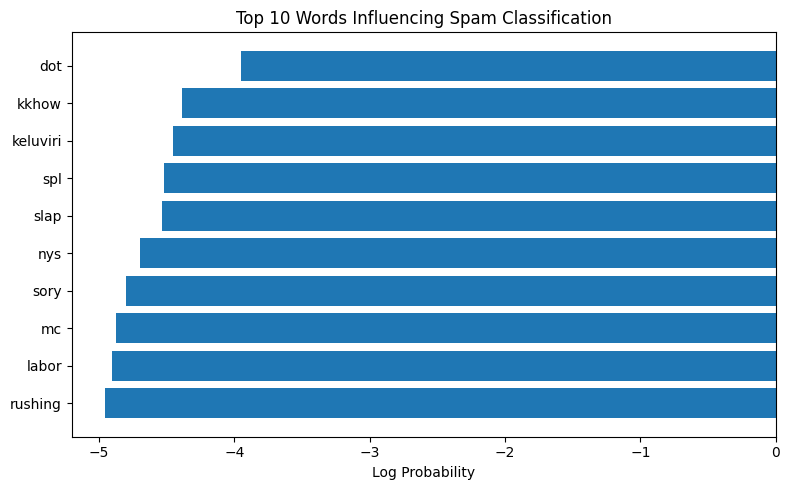

In [17]:

import numpy as np
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()
spam_log_probs = model.feature_log_prob_[1]

min_len = min(len(feature_names), len(spam_log_probs))

feature_names = feature_names[:min_len]
spam_log_probs = spam_log_probs[:min_len]

top_indices = np.argsort(spam_log_probs)[-10:]
top_words = feature_names[top_indices]
top_values = spam_log_probs[top_indices]

plt.figure(figsize=(8,5))
plt.barh(top_words, top_values)
plt.xlabel("Log Probability")
plt.title("Top 10 Words Influencing Spam Classification")
plt.tight_layout()
plt.show()

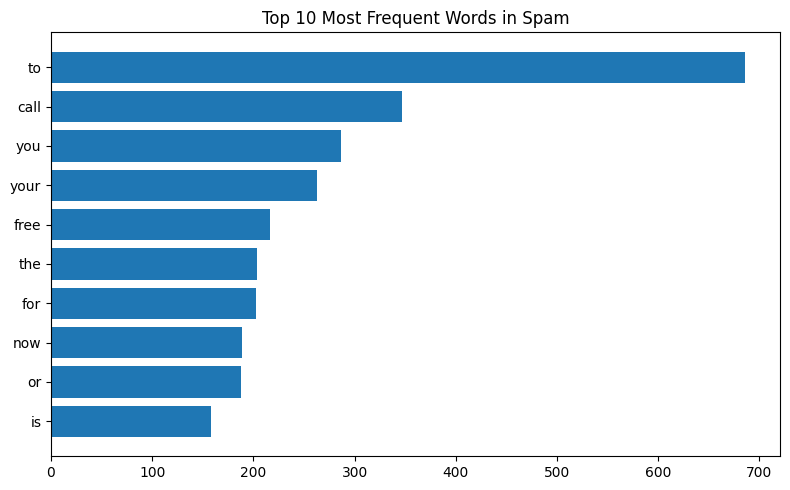

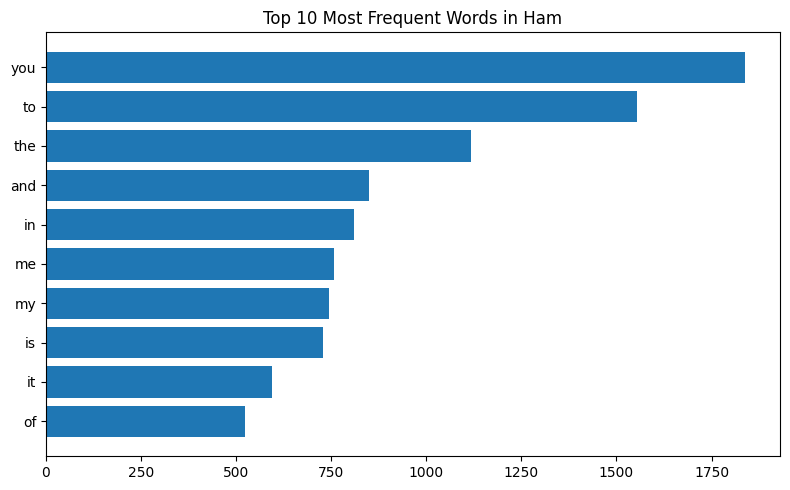

In [18]:
#  Word Frequency Comparison (Spam vs Ham)
spam_messages = df[df['label'] == 'spam']['message']
ham_messages = df[df['label'] == 'ham']['message']

spam_vector = CountVectorizer()
ham_vector = CountVectorizer()

spam_matrix = spam_vector.fit_transform(spam_messages)
ham_matrix = ham_vector.fit_transform(ham_messages)

spam_word_counts = np.asarray(spam_matrix.sum(axis=0)).flatten()
ham_word_counts = np.asarray(ham_matrix.sum(axis=0)).flatten()

spam_words = spam_vector.get_feature_names_out()
ham_words = ham_vector.get_feature_names_out()

spam_top_idx = np.argsort(spam_word_counts)[-10:]
ham_top_idx = np.argsort(ham_word_counts)[-10:]

plt.figure(figsize=(8,5))
plt.barh(spam_words[spam_top_idx], spam_word_counts[spam_top_idx])
plt.title("Top 10 Most Frequent Words in Spam")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.barh(ham_words[ham_top_idx], ham_word_counts[ham_top_idx])
plt.title("Top 10 Most Frequent Words in Ham")
plt.tight_layout()
plt.show()